In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

addArchRThreads(30)
options(repr.plot.width=15, repr.plot.height=10)


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==

In [18]:
ArchRProject


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(26): Sample TSSEnrichment ... celltype_v1 Tropho
numberOfCells(1): 34082
medianTSS(1): 3.615
medianFrags(1): 33602

Plotting

Warning message:
“Removed 31935 rows containing non-finite values (stat_summary_hex).”
Warning message:
“Removed 31935 rows containing non-finite values (stat_summary_hex).”


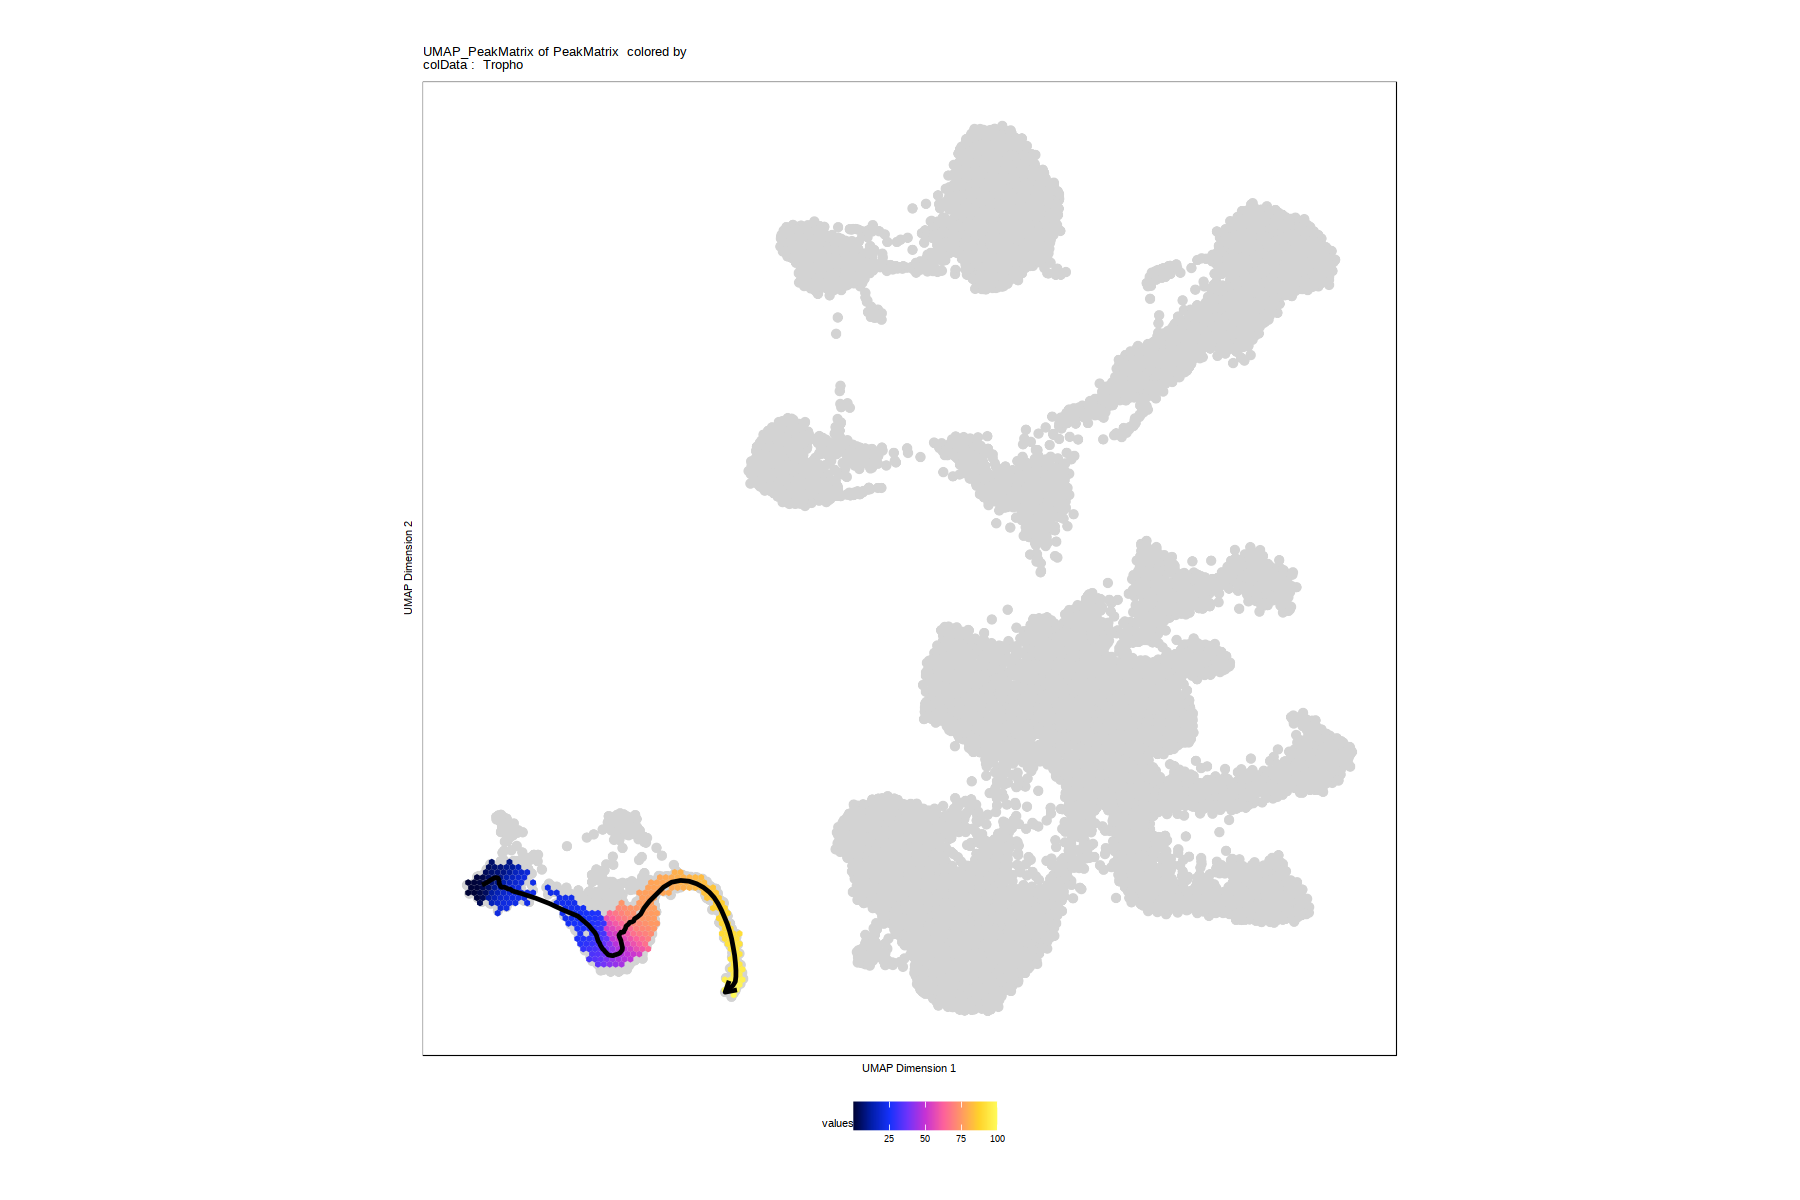

In [2]:
trajectory <- c('C3', 
                'C4', 
                'C1'
                )

ArchRProject <- addTrajectory(
    ArchRProj = ArchRProject, 
    name = "Tropho", 
    groupBy = "Clusters_PeakMatrix",
    trajectory = trajectory, 
    embedding = "UMAP_PeakMatrix",  ### Redudims but may look better based on embeddings
    force = TRUE
)

p <- plotTrajectory(ArchRProject, trajectory = "Tropho", colorBy = "cellColData", name = "Tropho", embedding = "UMAP_PeakMatrix")
p[[1]]

In [3]:
trajMM  <- getTrajectory(ArchRProj = ArchRProject, name = "Tropho", useMatrix = "MotifMatrix", log2Norm = FALSE)
names = sapply(strsplit(rownames(trajMM),":"), `[`, 2)
names = sapply(strsplit(names,"_"), `[`, 1)
rownames(trajMM) = names

Creating Trajectory Group Matrix..

Some values are below 0, this could be a DeviationsMatrix in which scaleTo should be set = NULL.
Continuing without depth normalization!

Smoothing...



2022-05-03 09:38:05 : SuppressedMessaged due to getArchRVerbose() is FALSE!

2022-05-03 09:38:05 : SuppressedMessaged due to getArchRVerbose() is FALSE!

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



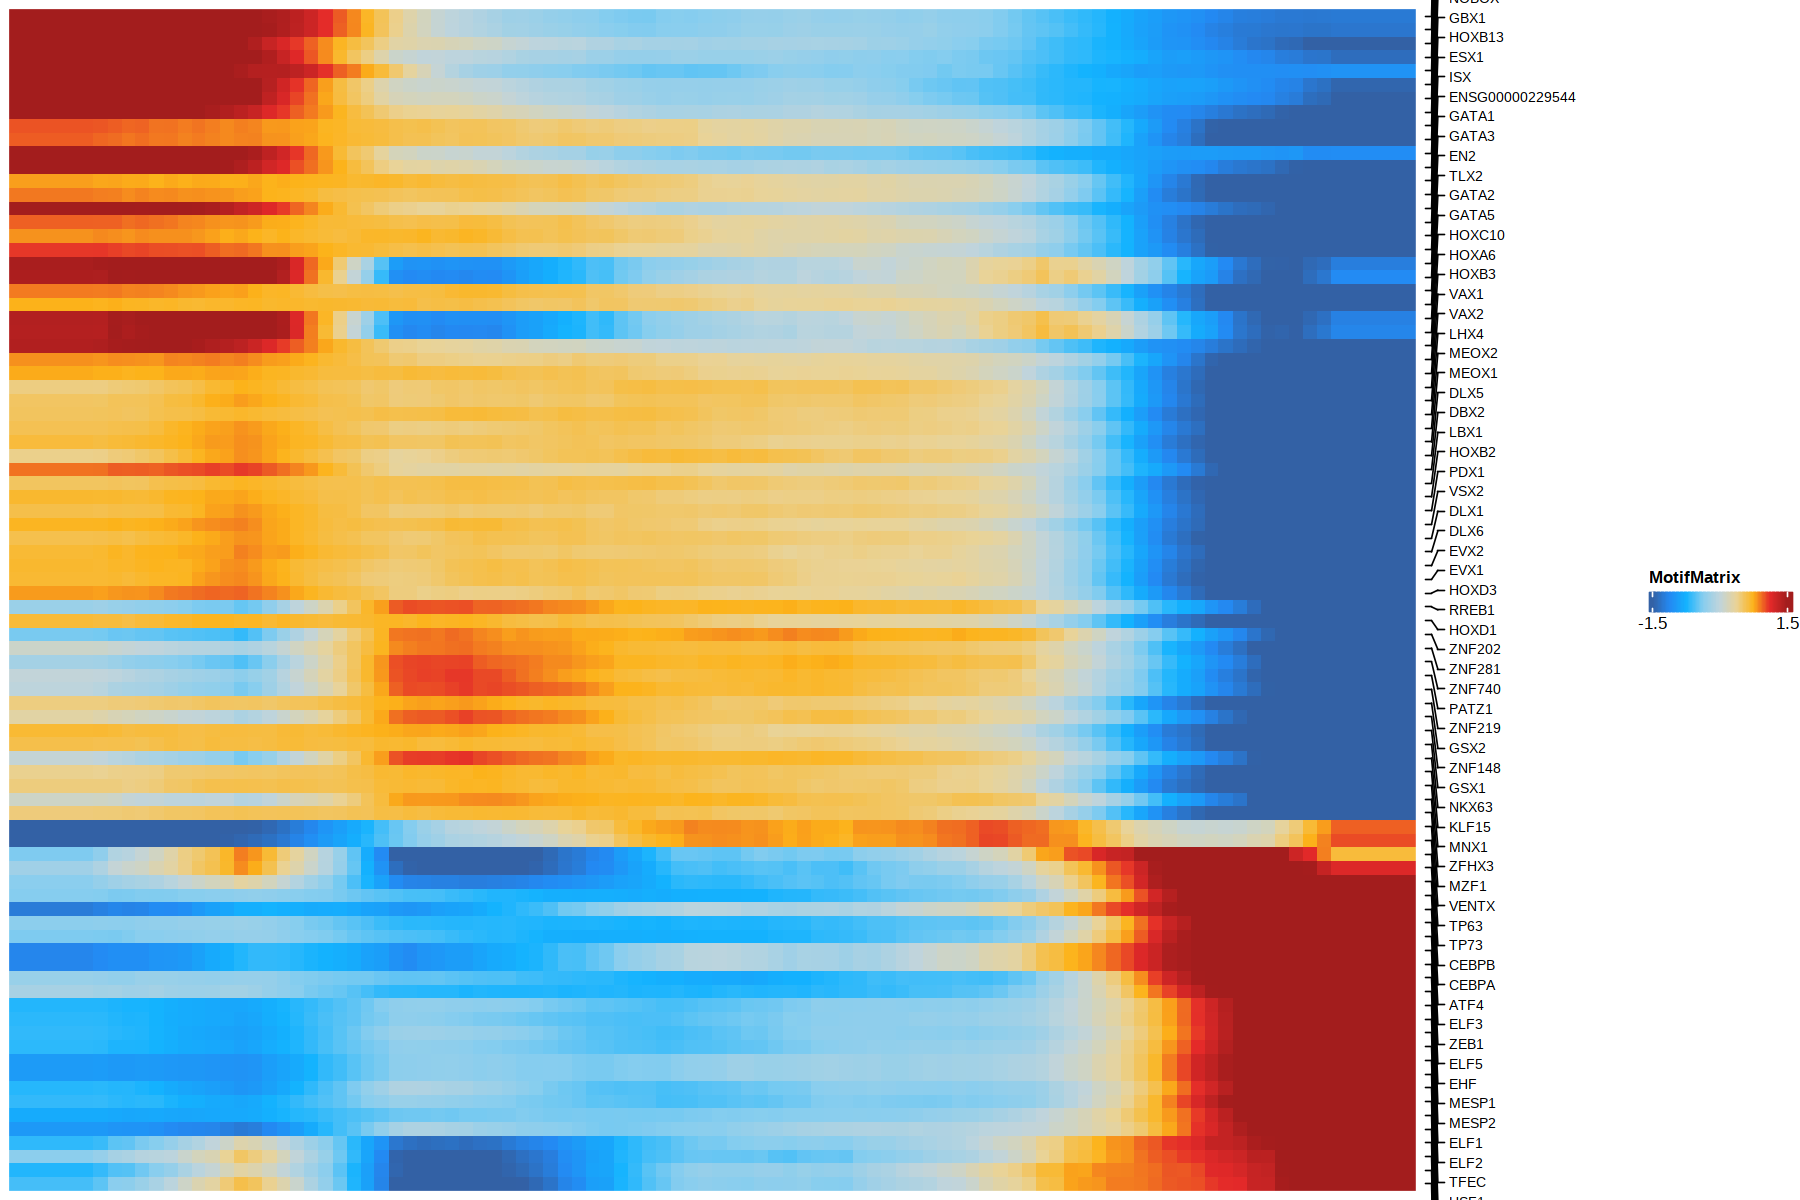

In [4]:
p1 = plotTrajectoryHeatmap(trajMM, pal = paletteContinuous(set = "solarExtra"), labelTop  = 100)
p1

In [5]:
TF_plot = c("CDX2", "TEAD4", "DLX5", "HAND1", "DLX6","PATZ1", "ZNF740",
"TP63", "GRHL1", "CEBPA","ELF3", "MITF", "TFEB","TFAP2C", "TFAP2A")

In [6]:
# exporting motif data for Dan so he can make one plot with RNA + ATAC
# Get gene score matrix
Motif = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "MotifMatrix")

# Rename columns & rows
gene_names = sapply(strsplit(Motif@elementMetadata$name,"_"), `[`, 1)
Motif = Motif@assays@data$z
rownames(Motif) = gene_names

meta = as.data.table(ArchRProject@cellColData, keep.rownames=TRUE)[,c('rn', 'sample', 'stage', 'celltype_v1', 'Tropho')] %>%
    setnames(c('rn', 'Tropho'), c('cell', 'Pseudotime'))
head(meta)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


cell,sample,stage,celltype_v1,Pseudotime
<chr>,<chr>,<chr>,<chr>,<dbl>
rabbit_BGRGP1#CAAGGCCGTATACGCT-1,rabbit_BGRGP1,GD7,Hypoblast_Parietal YS endoderm,NA
rabbit_BGRGP1#ATCCTCGTCCGAATTG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#CTTGCCATCTGAGTAC-1,rabbit_BGRGP1,GD7,Nascent mesoderm_Epiblast,NA
rabbit_BGRGP1#AACAGTCTCCGATGCG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#GGTGAAGTCGTCGCAG-1,rabbit_BGRGP1,GD7,Epiblast,NA
rabbit_BGRGP1#ATCGAGTAGAGGAATG-1,rabbit_BGRGP1,GD7,Epiblast,NA


In [7]:
options(repr.plot.width=15, repr.plot.height=6)


In [8]:
# Get in long format, add meta, add zscore, smooth
plot_motif = as.data.table(as.matrix(Motif)) %>%
    .[,TF:=gene_names] %>% 
    melt(id.vars = 'TF') %>%
    setnames('variable','cell') %>% 
    merge(meta, by='cell') %>%
    .[!is.na(Pseudotime)] %>% 
    .[,zscore:= scale(value), by=TF] %>% 
    .[order(Pseudotime)] %>%  
    .[, zscore_smooth:=frollmean(zscore, 10), by = TF] %>% 
    .[,zscore_capped:=ifelse(zscore>=1.5, 1.5, ifelse(zscore<=-1.5, -1.5, zscore))] %>%
    .[,zscore_smooth_capped:=ifelse(zscore_smooth>=1.5, 1.5, ifelse(zscore_smooth<=-1.5, -1.5, zscore_smooth))]

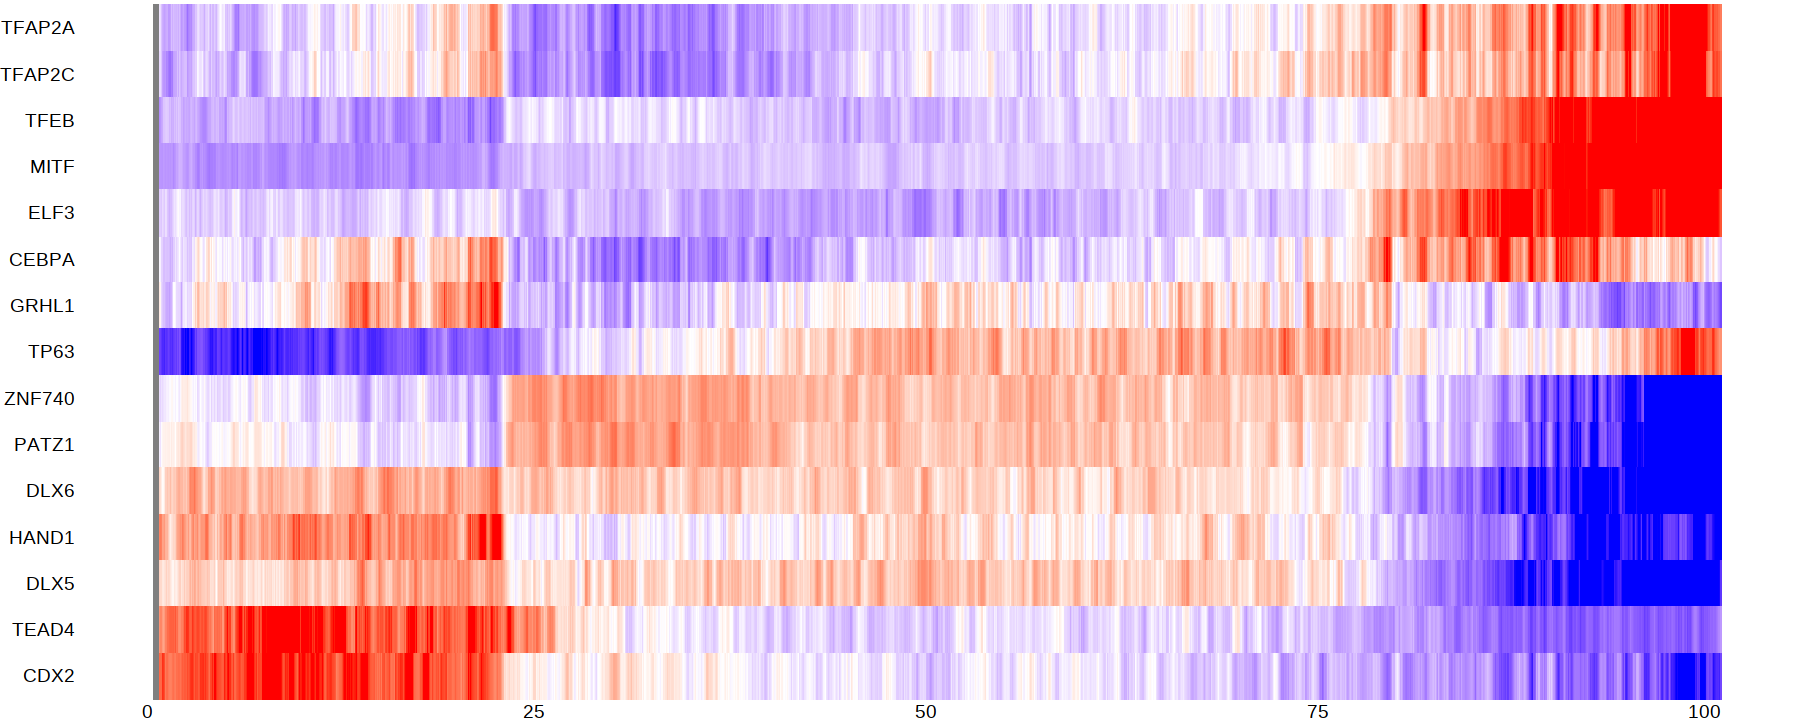

In [9]:
ggplot(plot_motif[TF %in% TF_plot & !is.na(Pseudotime)], aes(Pseudotime,factor(TF, levels=TF_plot), fill=zscore_smooth_capped)) + geom_tile() + scale_fill_gradient2(low = "blue", mid = "white", high = "red") + theme_void() + theme(axis.text = element_text(hjust=1), legend.position='none')

In [10]:
ArchRProject = addImputeWeights(ArchRProject, reducedDims = 'PeakMatrix')

Warning message in sprintf("Completed Getting Magic Weights!", round(object.size(weightList)/10^9, :
“one argument not used by format 'Completed Getting Magic Weights!'”


In [11]:
imputed_motif = suppressMessages(imputeMatrix(mat = as.matrix(Motif), 
                                imputeWeights = getImputeWeights(ArchRProject)))

In [12]:
# Get in long format, add meta, add zscore, smooth
plot_motif = as.data.table(as.matrix(imputed_motif)) %>%
    .[,TF:=gene_names] %>% 
    melt(id.vars = 'TF') %>%
    setnames('variable','cell') %>% 
    merge(meta, by='cell') %>%
    .[!is.na(Pseudotime)] %>% 
    .[,zscore:= scale(value), by=TF] %>% 
    .[order(Pseudotime)] %>%  
    .[, zscore_smooth:=frollmean(zscore, 10), by = TF] %>% 
    .[,zscore_capped:=ifelse(zscore>=1.5, 1.5, ifelse(zscore<=-1.5, -1.5, zscore))] %>%
    .[,zscore_smooth_capped:=ifelse(zscore_smooth>=1.5, 1.5, ifelse(zscore_smooth<=-1.5, -1.5, zscore_smooth))]

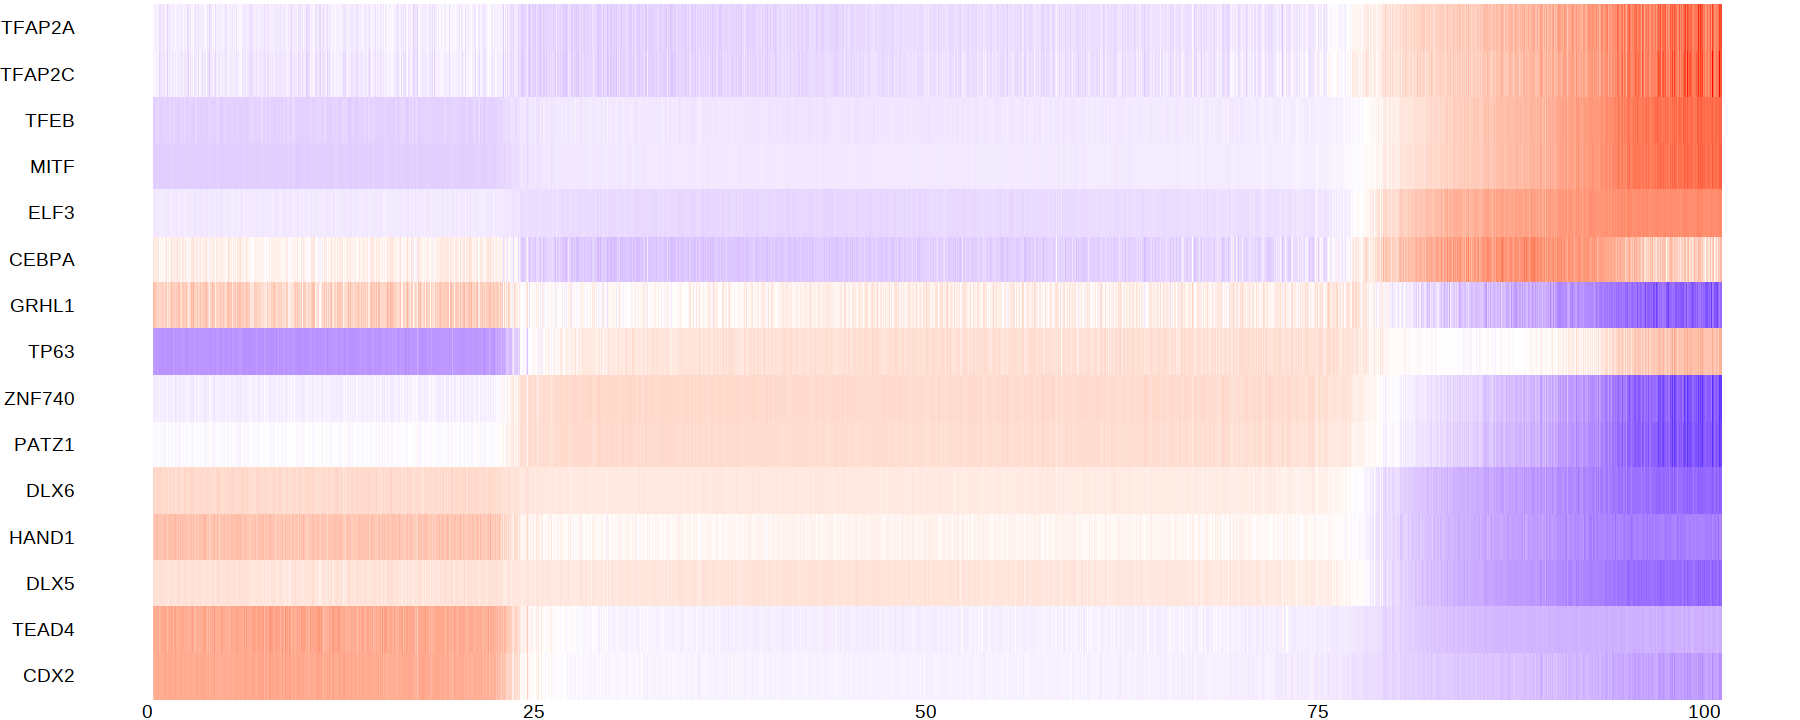

In [17]:
ggplot(plot_motif[TF %in% TF_plot & !is.na(Pseudotime)], aes(Pseudotime,factor(TF, levels=TF_plot), fill=zscore)) + geom_tile() + scale_fill_gradient2(low = "blue", mid = "white", high = "red") + theme_void() + theme(axis.text = element_text(hjust=1), legend.position='none')

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



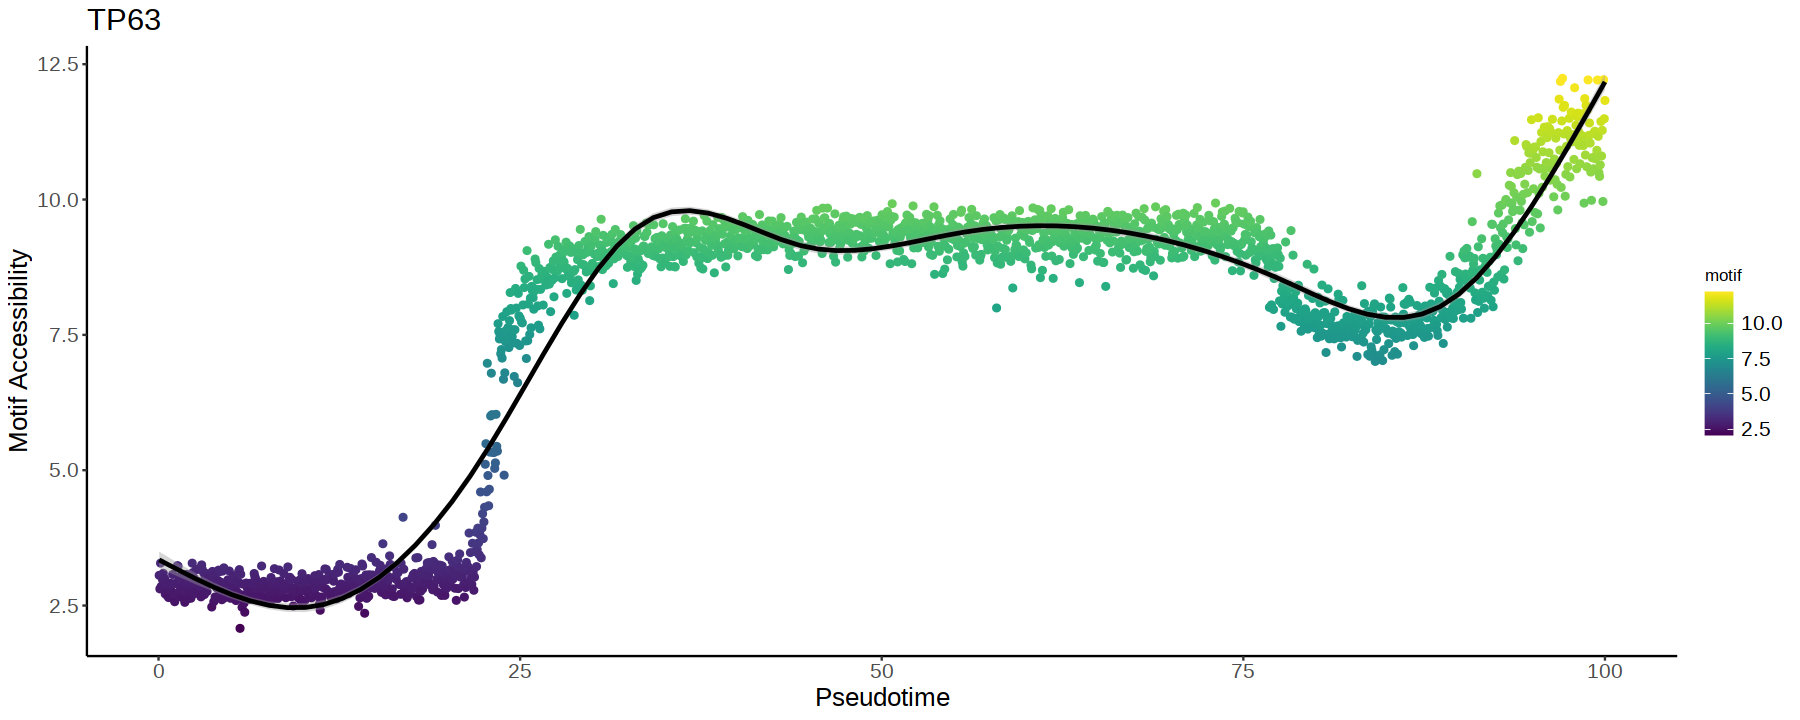

In [14]:
plot = function(gene){
    ggplot(plot_motif[TF == gene & !is.na(Pseudotime)], aes(Pseudotime, value, col=value)) +
        geom_point() +
        scale_color_viridis(option='viridis', name='motif') +
        geom_smooth(col='black') + 
        xlab('Pseudotime') + ylab('Motif Accessibility') + 
        ggtitle(gene) +
        theme_classic() + 
        theme(text = element_text(size = 15), 
              legend.title=element_text(size=10))
}
plot('TP63')

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



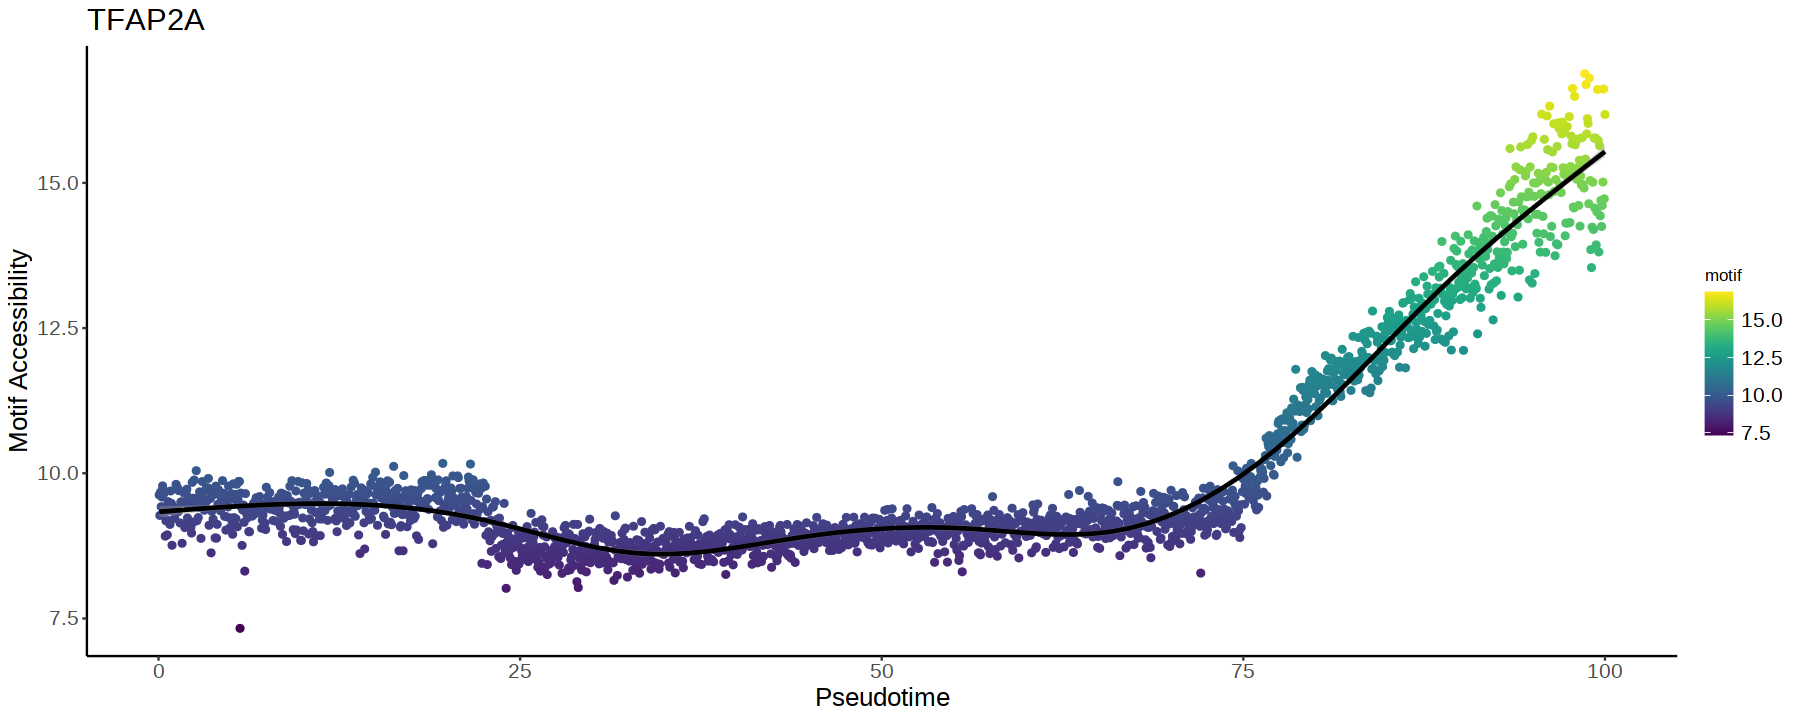

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



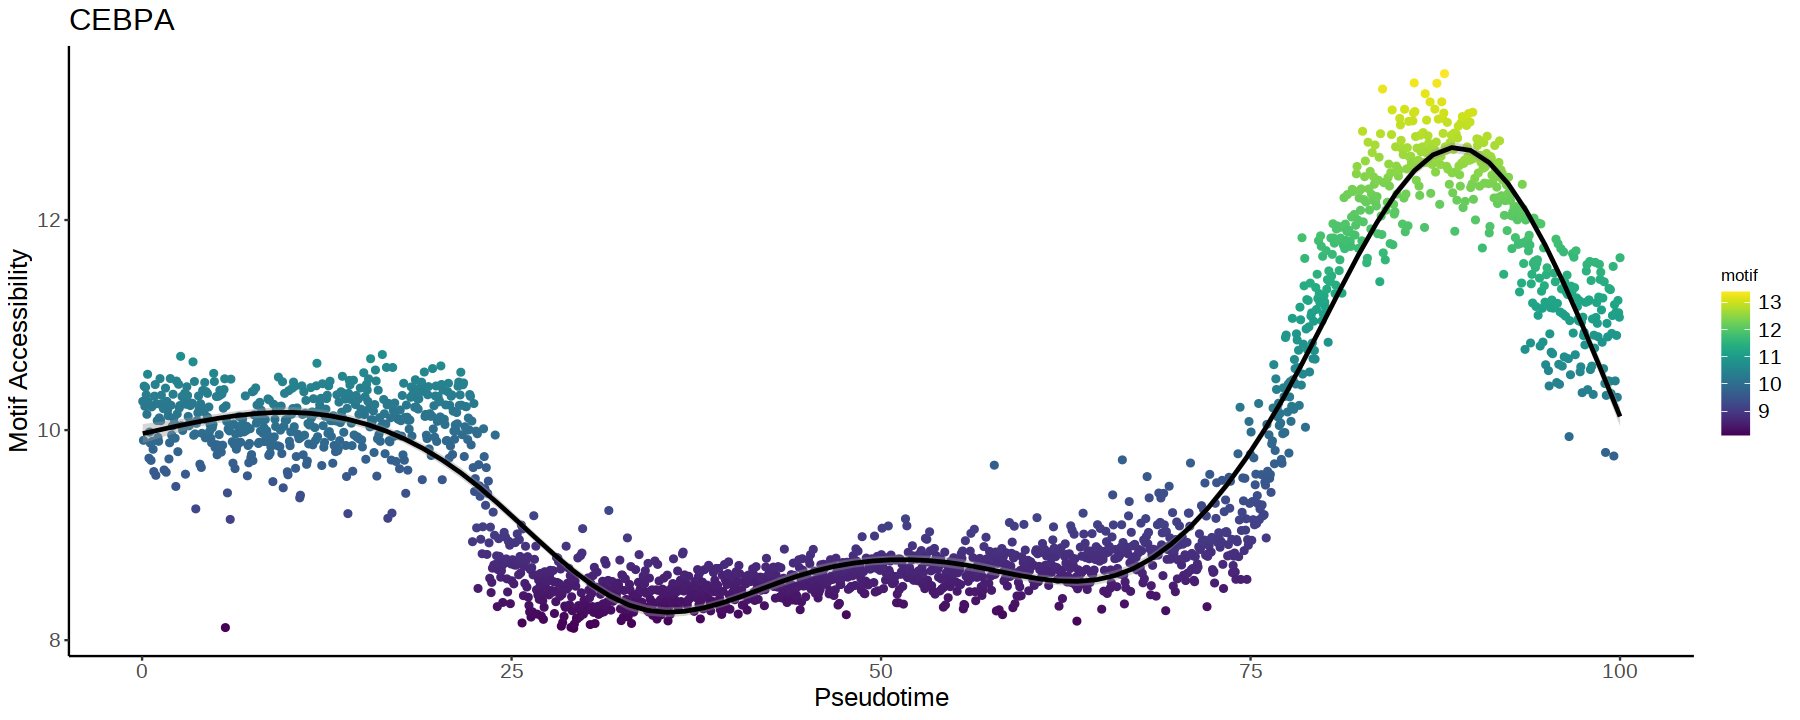

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



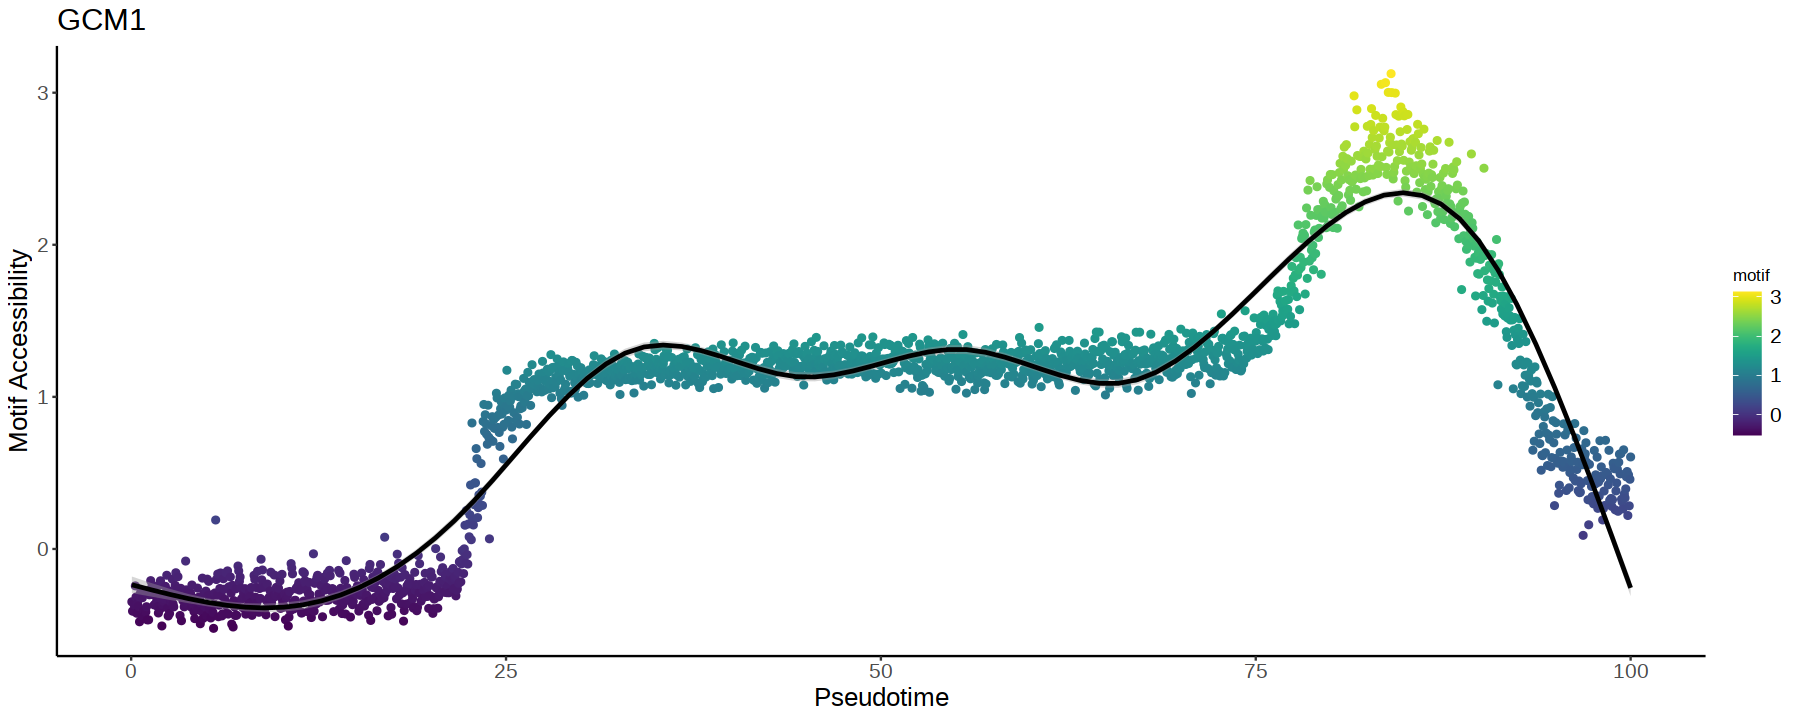

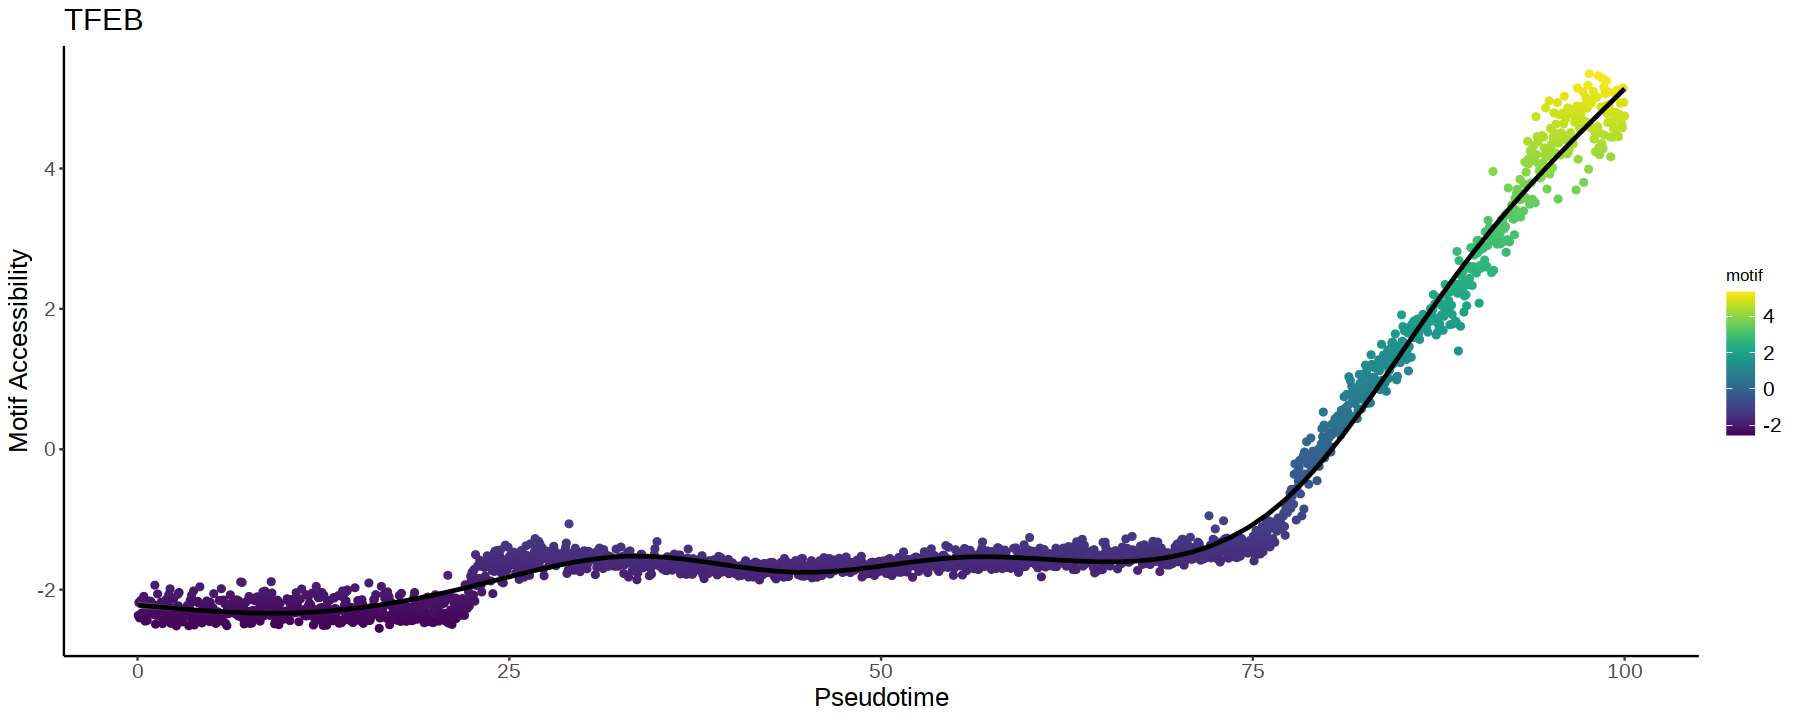

In [16]:
plot('TFAP2A')
plot('CEBPA')
plot('GCM1')
plot('TFEB')


In [ ]:
e = "Tropho", 
    groupBy = "Clusters_PeakMatrix",
    trajectory = trajectory, 
    embedding = "UMAP_PeakMatrix",  ### Redudims but may look better based on embeddings
    force = TRUE
)

In [86]:
ArchRProject = addSlingShotTrajectories(
  ArchRProj = ArchRProject,
  name = "slingshot",
  groupBy = "Clusters_PeakMatrix",
  useGroups = trajectory,
  principalGroup = 'C3',
  embedding  = "UMAP_PeakMatrix", 
 # reducedDims = 'PeakMatrix', # This option does not work!
  seed = 42
)

ERROR: Error in addCellColData(ArchRProj = ArchRProj, data = as.vector(ptn[, : Error previous entry for slingshot.Curve1, Set force = TRUE to override!


Warning message:
“Removed 4 row(s) containing missing values (geom_path).”


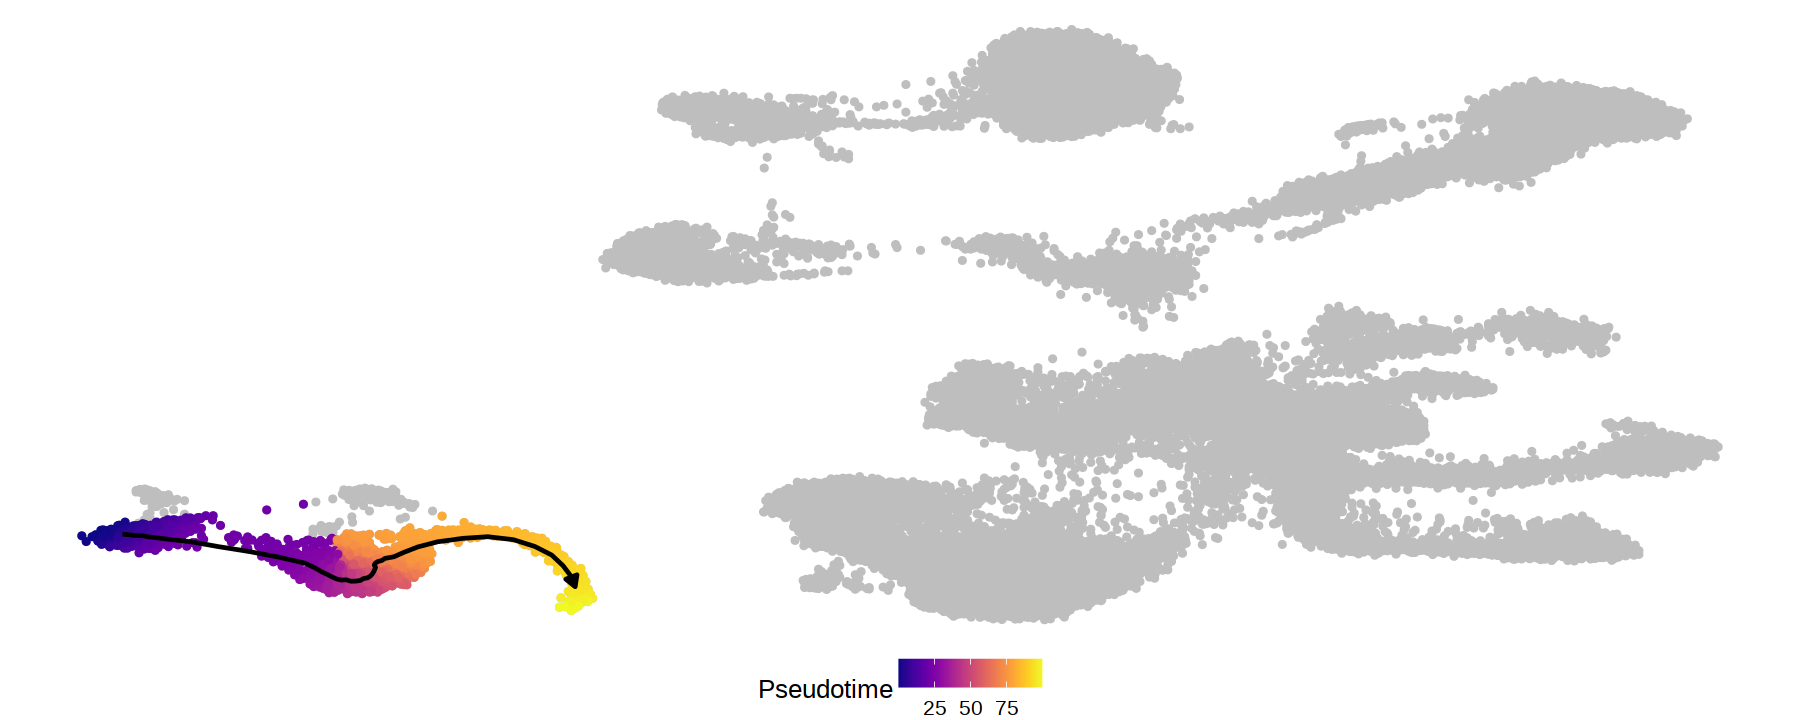

In [85]:
# Fetch UMAP coordinates
umap.dt <- getEmbedding(ArchRProject,paste0("UMAP_PeakMatrix")) %>%
  round(2) %>%
  as.data.table(keep.rownames = T) %>%
  setnames(c("cell","umap1","umap2"))

# Plot
sample_metadata = as.data.frame(getCellColData(ArchRProject))
to.plot <- umap.dt %>%
  merge(sample_metadata,by="cell")

# Add arrow
bin = 2
k = 5

to.plot$pseudobin = cut(to.plot$slingshot.Curve1, breaks=seq(0, 100, bin))
arrow = to.plot[!is.na(Tropho),list(median(umap1), median(umap2)), 
                                  by= pseudobin] %>%
        setnames(c('V1', 'V2'), c('umap1', 'umap2')) %>% .[order(pseudobin),]
# Smooth out the arrow
arrow = arrow[,c('smooth1', 'smooth2'):=list(frollmean(umap1, n = k, align = "right"),
                                      frollmean(umap2, n = k, align = "right"))]

p = ggplot(to.plot, aes(umap1, umap2)) + 
        geom_point(col='grey') + 
        geom_point(data=to.plot[!is.na(to.plot$slingshot.Curve1),], aes(umap1, umap2, col=slingshot.Curve1)) + 
        scale_color_viridis(option='plasma', name='Pseudotime') + 
        theme_void() + theme(text=element_text(size=15), legend.position='bottom') +
        geom_path(data=arrow, aes(smooth1,smooth2),
                  size=1, 
                  arrow = arrow(type = "closed", angle = 30, length = unit(0.1, "inches")))
p

In [81]:
p <- plotTrajectory(ArchRProject, trajectory = "Tropho", colorBy = "cellColData", name = "slingshot.Curve1", embedding = "UMAP_PeakMatrix")
p[[1]]

ERROR: Error in quantile.default(x, probs = c(lo, hi)): missing values and NaN's not allowed if 'na.rm' is FALSE


In [40]:
getMonocleTrajectories(
  ArchRProj = ArchRProject,
  name = "Trajectory",
  groupBy = "Clusters_PeakMatrix",
  useGroups = trajectory,
  principalGroup = 'C3',
  embedding  = "UMAP_PeakMatrix",
  clusterParams = list(),
  graphParams = list(),
  seed = 42)

Running Monocole3 Trajectory Infrastructure!

Adding Embedding

Clustering Embedding

Learning Graphs



  |======================================================================| 100%


Getting Principal Node

Ordering Cells

Plotting Results - /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR/Project/Monocole3/Plot-Results-Trajectory.pdf



class: cell_data_set 
dim: 3 2386 
metadata(2): cds_version citations
assays(1): counts
rownames: NULL
rowData names(0):
colnames(2386): rabbit_BGRGP1#GCTCAGGAGATGGGAA-1
  rabbit_BGRGP1#ACAGAAATCACTCCCA-1 ... rabbit_BGRGP4#GGAACCCGTTCTTATC-1
  rabbit_BGRGP4#TATCTGTCATTGCCTC-1
colData names(26): Sample TSSEnrichment ... celltype_v1 Tropho
reducedDimNames(1): UMAP
mainExpName: NULL
altExpNames(0):